# Student Bags: Exploratory Data Analysis (EDA)
## Problem Statement
Students frequently need to carry a laptop and deal with rain at the start of 2026. They have to prioritize bags equipped with a laptop compartment and a waterproof feature.

Are these two needs (Waterproof & Laptop Compartment) reflected in the bag's price? Or are there other attributes that matter more?

The dataset consists of 12,805 rows & 10 columns.

*This notebook continues from Mini Project 1 (Data Cleaning). The cleaning steps below are re-run here so this notebook can execute standalone; see `Student_Bags_Data_Cleaning.ipynb` for the full reasoning behind each cleaning decision.*

# RECAP: DATA CLEANING (from Mini Project 1)

## IMPORT & LOAD

In [1]:
import pandas as pd # import and analyze tabular data
import numpy as np # for computing the PMF (statistical analysis)
import matplotlib.pyplot as plt # for basic visualizations
import seaborn as sns # for statistical visualizations
import plotly.express as px # interactive visualization
import plotly.io as pio # Plotly renderer setting
pio.renderers.default = 'iframe'

df=pd.read_csv('tsb.csv') # load the original dataset already stored in Jupyter. File renamed to "tsb" for convenience.
df_asli=df.copy() # create a backup dataset to be used later as a before/after comparison after preprocessing.

df.head() # show the first 5 rows. Useful for seeing what the dataset structure looks like.

,Brand,Material,Size,Compartments,Laptop Compartment,Waterproof,Style,Color,Weight Capacity (kg),Price
0,Nike,Nylon,Small,9.0,No,No,Tote,Black,9.333159,116.655111
1,Adidas,Polyester,Large,NaN,No,No,Backpack,Gray,26.258602,127.225657
2,Under Armour,Nylon,Medium,7.0,No,No,Backpack,Blue,15.049938,132.131249
3,Under Armour,Canvas,Large,8.0,Yes,No,Tote,Green,17.426660,NaN
4,Puma,NaN,Large,1.0,No,Yes,Backpack,Black,12.771516,86.334448


## HANDLING MISSING VALUES

In [2]:
df['Brand']=df['Brand'].fillna('Unknown') # fill with "Unknown" for 2 variables: Brand and Color.
df['Color']=df['Color'].fillna('Unknown')

for col in ['Material', 'Size', 'Style',
            'Laptop Compartment', 'Waterproof']:
    df[col]=df[col].fillna(df[col].mode()[0]) 

# fill the remaining 5 variables with the mode.
# these variables have few, well-defined categories with a near-uniform distribution. Every bag must be made of something, must have a size, and must have a style.
# want to preserve the Yes/No structure for 0/1 encoding (Waterproof & Laptop Compartment variables)

df['Compartments']=df['Compartments'].fillna(df['Compartments'].mode()[0])

# also fill with the mode because Compartments is a whole number. Filling with the mean could introduce decimal values.

df['Weight Capacity (kg)']=df['Weight Capacity (kg)'].fillna(
    df['Weight Capacity (kg)'].median()
)

# fill Weight Capacity with the median because it's a continuous variable where the median is not affected by extreme values.

# leave Price missing values empty because Price is the key variable in this analysis, and filling it with the mean/median could distort the data's distribution.

print(df.isnull().sum()) # confirm that the missing value filling process is complete. Now only Price still has missing values.

Brand                     0
Material                  0
Size                      0
Compartments              0
Laptop Compartment        0
Waterproof                0
Style                     0
Color                     0
Weight Capacity (kg)      0
Price                   624
dtype: int64


## STANDARDIZING FORMAT & DATA TYPES

In [3]:
df.columns=df.columns.str.strip() # remove extra whitespace
df.columns=df.columns.str.replace(' ', '_').str.replace(r'[()]', '', regex=True)
# standardize column names: remove spaces and parentheses for easier coding

df['Weight_Capacity_kg']=df['Weight_Capacity_kg'].round(2) # round to 2 decimal places, sufficient precision for weight in kg

for col in ['Brand', 'Material', 'Size', 'Style', 'Color',
            'Laptop_Compartment', 'Waterproof']:
    df[col]=df[col].astype('category')

# convert categorical columns to the category dtype for memory efficiency

In [4]:
df['Compartments']=df['Compartments'].astype(int) # convert to integer since a bag cannot have a fractional number of compartments

df.info() # check the conversion result

<class 'pandas.DataFrame'>
RangeIndex: 12805 entries, 0 to 12804
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   Brand               12805 non-null  category
 1   Material            12805 non-null  category
 2   Size                12805 non-null  category
 3   Compartments        12805 non-null  int64   
 4   Laptop_Compartment  12805 non-null  category
 5   Waterproof          12805 non-null  category
 6   Style               12805 non-null  category
 7   Color               12805 non-null  category
 8   Weight_Capacity_kg  12805 non-null  float64 
 9   Price               12181 non-null  float64 
dtypes: category(7), float64(2), int64(1)
memory usage: 388.1 KB


## SUMMARY

In [5]:
print("Dataset Condition (Post-Cleaning)")
print(f"Shape               : {df.shape}")
print(f"Missing Values      : {df.isnull().sum().sum()} (Price, 624 rows)")
print(f"Duplicates          : {df.duplicated().sum()}")

# Price NaN is intentionally left unfilled to preserve the distribution and avoid disrupting the visualization stage
# if all NaN rows were dropped from the raw data, ~40% of the data would be lost.
# decision: fill per column, then drop Price missing values (new dataframe called df_viz) for visualization and analysis.

# key variables:
# Price            : the variable being analyzed
# functional features : Waterproof, Laptop_Compartment, nilai_fungsional
# physical features   : Size, Weight_Capacity_kg, Compartments
# identity features   : Brand, Material, Style, Color

display(df.head())
display(df.describe())

Dataset Condition (Post-Cleaning)
Shape               : (12805, 10)
Missing Values      : 624 (Price, 624 rows)
Duplicates          : 0


,Brand,Material,Size,Compartments,Laptop_Compartment,Waterproof,Style,Color,Weight_Capacity_kg,Price
0,Nike,Nylon,Small,9,No,No,Tote,Black,9.33,116.655111
1,Adidas,Polyester,Large,5,No,No,Backpack,Gray,26.26,127.225657
2,Under Armour,Nylon,Medium,7,No,No,Backpack,Blue,15.05,132.131249
3,Under Armour,Canvas,Large,8,Yes,No,Tote,Green,17.43,NaN
4,Puma,Polyester,Large,1,No,Yes,Backpack,Black,12.77,86.334448


,Compartments,Weight_Capacity_kg,Price
count,12805.000000,12805.000000,12181.000000
mean,5.509098,17.527142,81.748538
std,2.789476,7.364781,39.271530
min,1.000000,5.000000,15.000000
25%,3.000000,11.420000,47.379405
50%,5.000000,17.590000,81.312176
75%,8.000000,23.800000,115.715245
max,10.000000,30.000000,150.000000


## DISTRIBUTION

### NUMERIC DISTRIBUTION

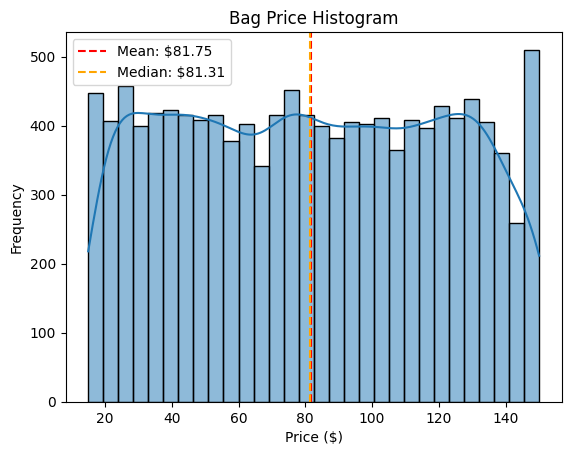

In [6]:
# price distribution: shows the range and pattern of prices in the market
# kde=True: adds a distribution curve
sns.histplot(df['Price'].dropna(), bins=30, kde=True)
plt.axvline(df['Price'].dropna().mean(), color='red',
            linestyle='--', linewidth=1.5,
            label=f"Mean: ${df['Price'].dropna().mean():.2f}")
plt.axvline(df['Price'].dropna().median(), color='orange',
            linestyle='--', linewidth=1.5,
            label=f"Median: ${df['Price'].dropna().median():.2f}")
plt.legend()
plt.title('Bag Price Histogram')
plt.xlabel('Price ($)')
plt.ylabel('Frequency')
plt.show()

# INTERPRETATION:
# the price distribution appears uniform across the $15-$150 range.
# product counts are roughly even across that range.
# mean ($81.75) and median ($81.31) are very close. No significant skewness.

# no dominant price segment is visible

### CATEGORICAL DISTRIBUTION

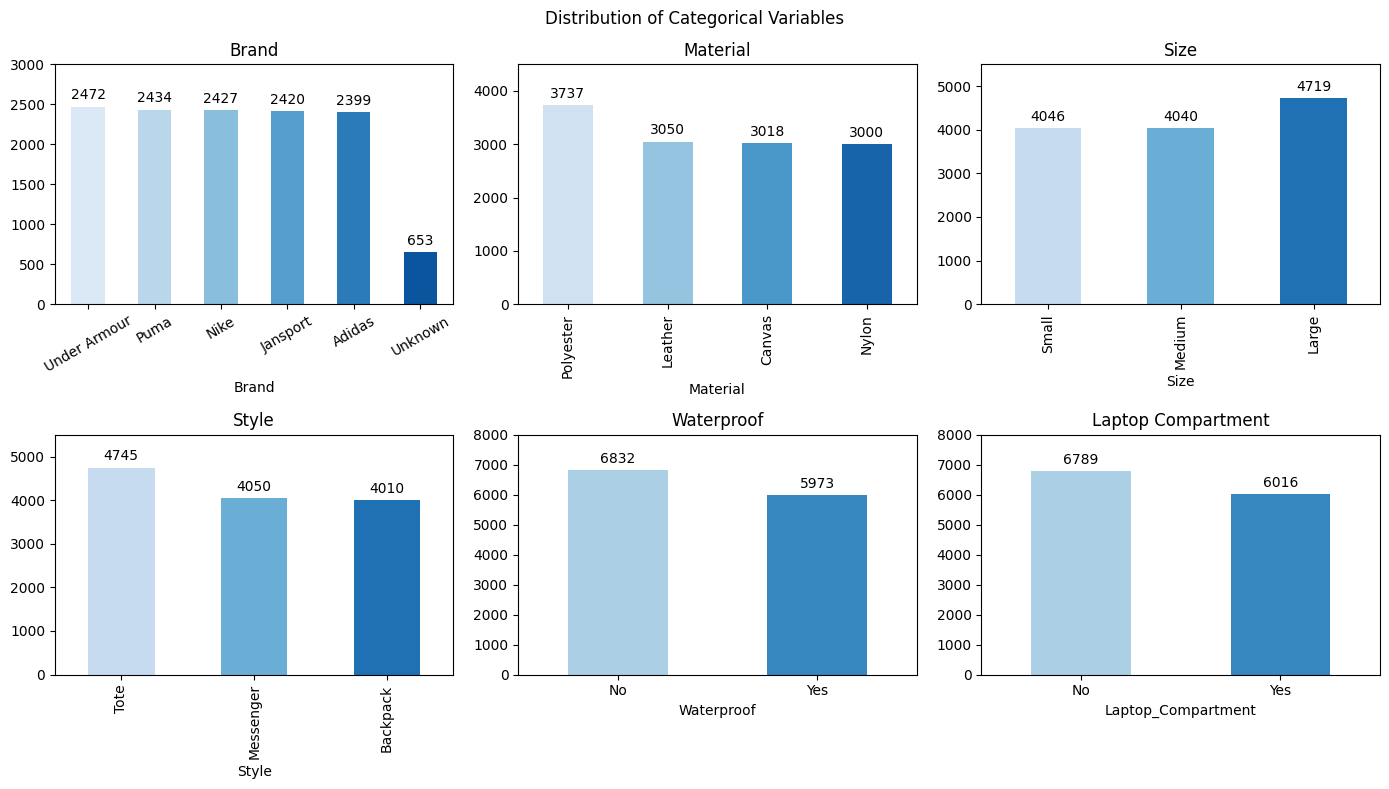

In [7]:
# univariate analysis of categorical variables: shows market composition
# value_counts(): counts the frequency of each category
# plot(kind='bar'): displays it as a bar chart

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
fig.suptitle('Distribution of Categorical Variables')

# Brand
ax1 = df['Brand'].value_counts().plot(kind='bar', ax=axes[0,0],
      color=sns.color_palette('Blues', 6))
axes[0,0].bar_label(axes[0,0].containers[0], padding=3)
axes[0,0].set_title('Brand')
axes[0,0].tick_params(axis='x', rotation=30)
axes[0,0].set_ylim(0, 3000) 

# Material
ax2 = df['Material'].value_counts().plot(kind='bar', ax=axes[0,1],
      color=sns.color_palette('Blues', 4))
axes[0,1].bar_label(axes[0,1].containers[0], padding=3)
axes[0,1].set_title('Material')
axes[0,1].set_ylim(0, 4500)

# Size
ax3 = df['Size'].value_counts().reindex(['Small','Medium','Large']).plot(
      kind='bar', ax=axes[0,2], color=sns.color_palette('Blues', 3))
axes[0,2].bar_label(axes[0,2].containers[0], padding=3)
axes[0,2].set_title('Size')
axes[0,2].set_ylim(0, 5500)

# Style
ax4 = df['Style'].value_counts().plot(kind='bar', ax=axes[1,0],
      color=sns.color_palette('Blues', 3))
axes[1,0].bar_label(axes[1,0].containers[0], padding=3)
axes[1,0].set_title('Style')
axes[1,0].set_ylim(0, 5500)

# Waterproof
ax5 = df['Waterproof'].value_counts().plot(kind='bar', ax=axes[1,1],
      color=sns.color_palette('Blues', 2))
axes[1,1].bar_label(axes[1,1].containers[0], padding=3)
axes[1,1].set_title('Waterproof')
axes[1,1].set_ylim(0, 8000)
axes[1,1].tick_params(axis='x', rotation=0)

# Laptop Compartment
ax6 = df['Laptop_Compartment'].value_counts().plot(kind='bar', ax=axes[1,2],
      color=sns.color_palette('Blues', 2))
axes[1,2].bar_label(axes[1,2].containers[0], padding=3)
axes[1,2].set_title('Laptop Compartment')
axes[1,2].set_ylim(0, 8000)
axes[1,2].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

# INTERPRETATION:
# Brand: the 5 main brands are nearly even (~2,400 each).
# 'Unknown' (~640) is the result of filling Brand missing values in MP1.
# Material: Polyester is slightly more common, otherwise fairly even.
# Size: all three sizes are distributed fairly evenly.
# Style: Tote is slightly more common but not dominant.
# Waterproof & Laptop_Compartment: Yes/No are fairly balanced.

# categorical variables here visually show an even distribution, with no category being heavily dominant.
# this uniform distribution pattern suggests the dataset is likely synthetic.

## FINDING OUTLIERS

In [8]:
Q1=df['Weight_Capacity_kg'].quantile(0.25) # calculate Q1 & Q3 
Q3=df['Weight_Capacity_kg'].quantile(0.75)
IQR=Q3-Q1

lower=Q1-1.5*IQR # calculate lower and upper fences
upper=Q3+1.5*IQR

outlier_weight=df[(df['Weight_Capacity_kg'] < lower) | (df['Weight_Capacity_kg'] > upper)]
print(outlier_weight)

# the result shows an "Empty DataFrame", meaning no outliers were found.

Empty DataFrame
Columns: [Brand, Material, Size, Compartments, Laptop_Compartment, Waterproof, Style, Color, Weight_Capacity_kg, Price]
Index: []


In [9]:
Q1=df['Price'].quantile(0.25) # calculate Q1 & Q3
Q3=df['Price'].quantile(0.75)
IQR=Q3-Q1

lower=Q1-1.5*IQR # calculate lower and upper fences 
upper=Q3+1.5*IQR

outlier_price=df[(df['Price'] < lower) | (df['Price'] > upper)]
print(outlier_price)

# the result shows an "Empty DataFrame", meaning no outliers were found.

Empty DataFrame
Columns: [Brand, Material, Size, Compartments, Laptop_Compartment, Waterproof, Style, Color, Weight_Capacity_kg, Price]
Index: []


## OUTLIER VISUALIZATION

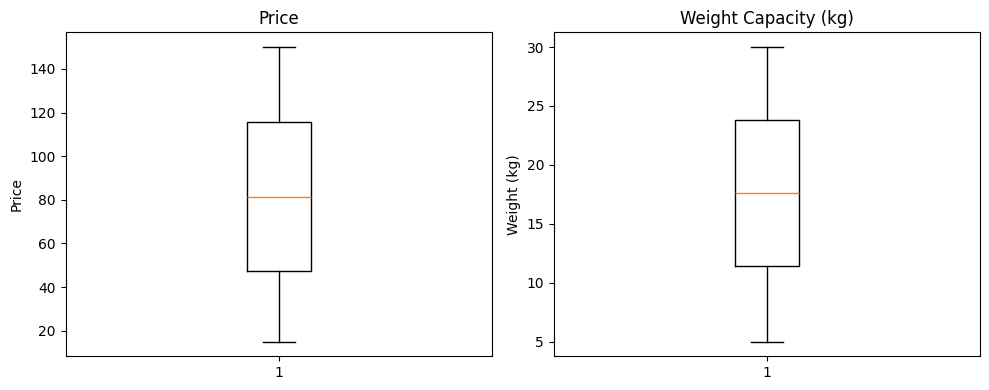

In [10]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.boxplot(df['Price'].dropna())
plt.title('Price')
plt.ylabel('Price')

plt.subplot(1, 2, 2)
plt.boxplot(df['Weight_Capacity_kg'])
plt.title('Weight Capacity (kg)')
plt.ylabel('Weight (kg)')

plt.tight_layout()
plt.show()

# boxplot visualization to confirm the spread of outliers. 
# no data points found outside the box.

## ENCODING

In [11]:
from sklearn.preprocessing import LabelEncoder

le=LabelEncoder()

df['Laptop_Compartment_Enc']=le.fit_transform(df['Laptop_Compartment'])
df['Waterproof_Enc']=le.fit_transform(df['Waterproof'])

df.head()

# converting Yes/No into 1/0 using LabelEncoder.
# stored as new columns so the original Yes/No labels remain available for groupby.

,Brand,Material,Size,Compartments,Laptop_Compartment,Waterproof,Style,Color,Weight_Capacity_kg,Price,Laptop_Compartment_Enc,Waterproof_Enc
0,Nike,Nylon,Small,9,No,No,Tote,Black,9.33,116.655111,0,0
1,Adidas,Polyester,Large,5,No,No,Backpack,Gray,26.26,127.225657,0,0
2,Under Armour,Nylon,Medium,7,No,No,Backpack,Blue,15.05,132.131249,0,0
3,Under Armour,Canvas,Large,8,Yes,No,Tote,Green,17.43,NaN,1,0
4,Puma,Polyester,Large,1,No,Yes,Backpack,Black,12.77,86.334448,0,1


## FEATURE ENGINEERING

In [12]:
df['nilai_fungsional']=df['Laptop_Compartment_Enc'] + df['Waterproof_Enc']

df.head()
# feature engineering to create a new column to be used for statistical analysis.
# summing the two encoded columns to get a "functional value" score.
# (nilai_fungsional = "functional value": 0=no feature, 1=one feature, 2=both features)
# 0=no feature, 1=one feature, 2=both features

,Brand,Material,Size,Compartments,Laptop_Compartment,Waterproof,Style,Color,Weight_Capacity_kg,Price,Laptop_Compartment_Enc,Waterproof_Enc,nilai_fungsional
0,Nike,Nylon,Small,9,No,No,Tote,Black,9.33,116.655111,0,0,0
1,Adidas,Polyester,Large,5,No,No,Backpack,Gray,26.26,127.225657,0,0,0
2,Under Armour,Nylon,Medium,7,No,No,Backpack,Blue,15.05,132.131249,0,0,0
3,Under Armour,Canvas,Large,8,Yes,No,Tote,Green,17.43,NaN,1,0,1
4,Puma,Polyester,Large,1,No,Yes,Backpack,Black,12.77,86.334448,0,1,1


## SUMMARY

In [13]:
print("===Before and After Preparation===")
print(f"Initial Shape          : {df_asli.shape}")
print(f"Final Shape             : {df.shape}")
print(f"Initial Missing Values : {df_asli.isnull().sum().sum()}")
print(f"Final Missing Values   : {df.isnull().sum().sum()}")

print("===VIEW===")
print("BEFORE:")
display(df_asli.head())

print("AFTER:")
display(df.head())

# comparison of the dataset before and after cleaning
# df_asli: original raw dataset (never modified)
# df: dataset that has been through cleaning & manipulation
# 3 new columns added

===Before and After Preparation===
Initial Shape          : (12805, 10)
Final Shape             : (12805, 13)
Initial Missing Values : 6493
Final Missing Values   : 624
===VIEW===
BEFORE:


,Brand,Material,Size,Compartments,Laptop Compartment,Waterproof,Style,Color,Weight Capacity (kg),Price
0,Nike,Nylon,Small,9.0,No,No,Tote,Black,9.333159,116.655111
1,Adidas,Polyester,Large,NaN,No,No,Backpack,Gray,26.258602,127.225657
2,Under Armour,Nylon,Medium,7.0,No,No,Backpack,Blue,15.049938,132.131249
3,Under Armour,Canvas,Large,8.0,Yes,No,Tote,Green,17.426660,NaN
4,Puma,NaN,Large,1.0,No,Yes,Backpack,Black,12.771516,86.334448


AFTER:


,Brand,Material,Size,Compartments,Laptop_Compartment,Waterproof,Style,Color,Weight_Capacity_kg,Price,Laptop_Compartment_Enc,Waterproof_Enc,nilai_fungsional
0,Nike,Nylon,Small,9,No,No,Tote,Black,9.33,116.655111,0,0,0
1,Adidas,Polyester,Large,5,No,No,Backpack,Gray,26.26,127.225657,0,0,0
2,Under Armour,Nylon,Medium,7,No,No,Backpack,Blue,15.05,132.131249,0,0,0
3,Under Armour,Canvas,Large,8,Yes,No,Tote,Green,17.43,NaN,1,0,1
4,Puma,Polyester,Large,1,No,Yes,Backpack,Black,12.77,86.334448,0,1,1


## DATAFRAME WITHOUT PRICE MISSING VALUES

In [14]:
df_viz=df.dropna(subset=['Price']) # create a new dataframe where Price missing values are removed, since analysis and visualization cannot process NaN.

df_viz.head()

,Brand,Material,Size,Compartments,Laptop_Compartment,Waterproof,Style,Color,Weight_Capacity_kg,Price,Laptop_Compartment_Enc,Waterproof_Enc,nilai_fungsional
0,Nike,Nylon,Small,9,No,No,Tote,Black,9.33,116.655111,0,0,0
1,Adidas,Polyester,Large,5,No,No,Backpack,Gray,26.26,127.225657,0,0,0
2,Under Armour,Nylon,Medium,7,No,No,Backpack,Blue,15.05,132.131249,0,0,0
4,Puma,Polyester,Large,1,No,Yes,Backpack,Black,12.77,86.334448,0,1,1
5,Adidas,Polyester,Medium,10,Yes,No,Tote,Black,11.04,115.392790,1,0,1


## FILTER

In [15]:
fitur_lengkap=df[(df['Laptop_Compartment_Enc'] == 1) & (df['Waterproof_Enc'] == 1)]
tanpa_fitur=df[(df['Laptop_Compartment_Enc'] == 0) & (df['Waterproof_Enc'] == 0)]

print(f"Bags with full features: {len(fitur_lengkap)}")
print(f"Bags with no features at all: {len(tanpa_fitur)}")

# comparing two groups: bags with both features vs. bags with no features at all.

# there are visibly more bags with no features at all.

Bags with full features: 2795
Bags with no features at all: 3611


In [16]:
# filtering choice: selecting a subset of data based on certain conditions, using '&' to combine multiple conditions for an "ideal" bag:
# condition 1: Size == 'Medium' --> a size that's not too small or too large for students
# condition 2: Laptop_Compartment == 'Yes' --> matches the needs of most students
# condition 3: Price <= 80 --> below the dataset average price ($81.75)
ideal = df[
    (df['Size'] == 'Medium') &
    (df['Laptop_Compartment'] == 'Yes') &
    (df['Price'] <= 80)
]
print(f"Ideal bags (medium size + has laptop compartment + price below $80): {len(ideal):,} bags ({len(ideal)/len(df_viz)*100:.1f}%)")
print(f"Also Waterproof: {len(ideal[ideal['Waterproof']=='Yes']):,} ({len(ideal[ideal['Waterproof']=='Yes'])/len(ideal)*100:.1f}%)")

# INTERPRETATION:
# there are 891 bags (7.3%) that meet the "ideal bag" criteria.
# of those, 413 bags (46.4%) also have the Waterproof feature.
# nearly 50% of "ideal" bags already come with both features without having to pay more than $80.

# students can find a Medium-sized bag with a Laptop Compartment under $80 from any brand.

Ideal bags (medium size + has laptop compartment + price below $80): 891 bags (7.3%)
Also Waterproof: 413 (46.4%)


## GROUPBY

In [17]:
print(df.groupby('Waterproof')['Price'].mean().round(2))
print(df.groupby('Laptop_Compartment')['Price'].mean().round(2))

# comparing the average price based on feature ownership.

# no significant price difference is visible.

Waterproof
No     82.01
Yes    81.46
Name: Price, dtype: float64
Laptop_Compartment
No     82.15
Yes    81.30
Name: Price, dtype: float64


In [18]:
result = df.groupby('nilai_fungsional')['Price'].agg(
    ['min', 'mean', 'max', 'count']).round(2)
result.index = ['0 (None)', '1 (One feature)', '2 (Full)']
result.columns = ['Min', 'Average', 'Max', 'Count']
print(result)

# INTERPRETATION:
# all three groups have an identical price range ($15-$150).
# interestingly, the average price DECREASES as features are added:
# No features    : $82.27
# One feature    : $81.86
# Full features  : $80.83
# bags with both features are actually CHEAPER on average than bags with no features at all, contrary to real-world expectations.

# functional features don't appear to add value that drives up price in this dataset.

                  Min  Average    Max  Count
0 (None)         15.0    82.27  150.0   3423
1 (One feature)  15.0    81.86  150.0   6083
2 (Full)         15.0    80.83  150.0   2675


## CROSS-TAB

In [19]:
ct = pd.crosstab(df['Brand'], df['Style'])
print(ct)

# INTERPRETATION:
# every brand offers all three styles (Backpack, Messenger, Tote) in a fairly even distribution.
# Tote slightly dominates for almost every brand: Adidas (893), Nike (924), Under Armour (920). The difference is relatively small, however.
# no brand appears to specialize in a particular style; all brands offer all styles fairly evenly.
# 'Unknown' has fewer entries across all styles (~200), simply because its total count is smaller (a result of filling Brand missing values in MP1)

Style         Backpack  Messenger  Tote
Brand                                  
Adidas             735        771   893
Jansport           757        786   877
Nike               767        736   924
Puma               782        778   874
Under Armour       760        792   920
Unknown            209        187   257


# FUNCTIONAL FEATURES: VISUALIZATION AND STATISTICAL ANALYSIS

## VISUALIZATION
---
Waterproof and Laptop Compartment are two features that students frequently look for.

Question: do the Waterproof and Laptop Compartment features actually affect price?

### PRICE COMPARISON

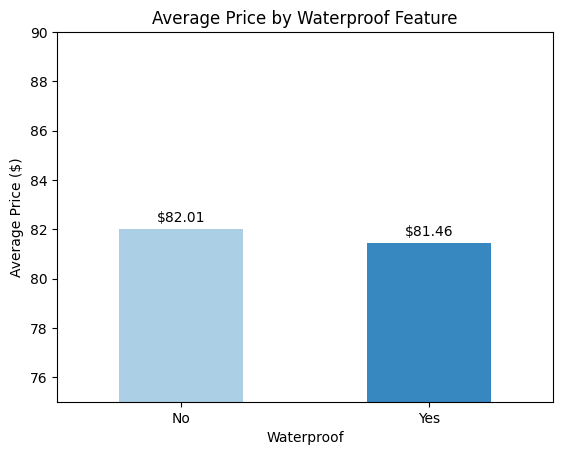

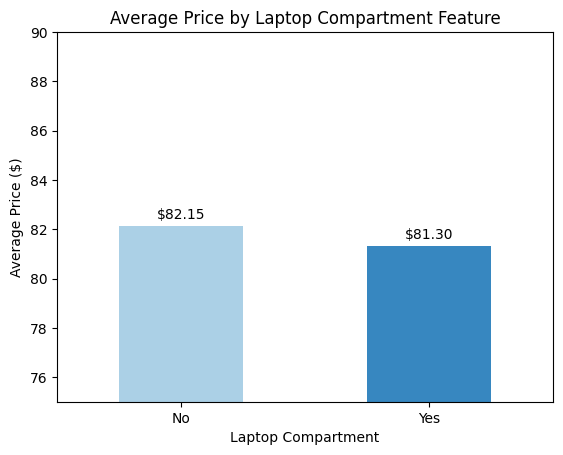

In [20]:
# comparing average price based on feature ownership
df_viz.groupby('Waterproof')['Price'].mean().plot(kind='bar', color=sns.color_palette('Blues', 2))
plt.title('Average Price by Waterproof Feature')
plt.xlabel('Waterproof')
plt.ylabel('Average Price ($)')
plt.bar_label(plt.gca().containers[0], fmt='$%.2f', padding=3)
plt.ylim(75, 90)
plt.xticks(rotation=0)
plt.show()

df_viz.groupby('Laptop_Compartment')['Price'].mean().plot(kind='bar', color=sns.color_palette('Blues', 2))
plt.title('Average Price by Laptop Compartment Feature')
plt.xlabel('Laptop Compartment')
plt.ylabel('Average Price ($)')
plt.bar_label(plt.gca().containers[0], fmt='$%.2f', padding=3)
plt.ylim(75, 90)
plt.xticks(rotation=0)
plt.show()

# INTERPRETATION:
# average price of bags with Waterproof ($81.46) vs without Waterproof ($82.01). A difference of only $0.55.
# the same pattern for Laptop Compartment: a difference of only $0.85 ($81.30 vs $82.15).

# the Waterproof and Laptop Compartment features do not appear to significantly affect price.

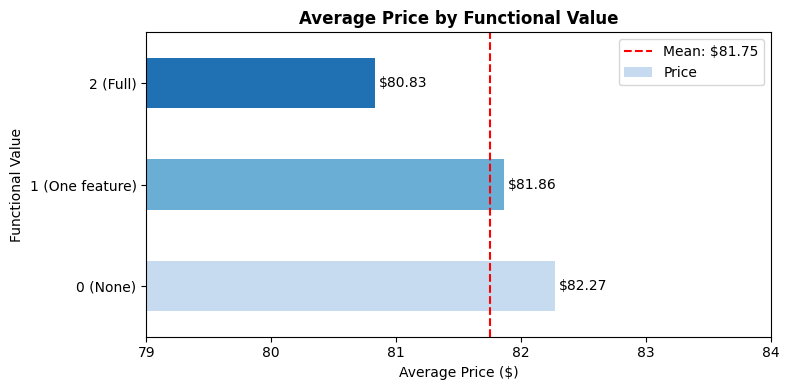

In [21]:
result = df_viz.groupby('nilai_fungsional')['Price'].mean().round(2)
result.index = ['0 (None)', '1 (One feature)', '2 (Full)']

result.plot(kind='barh',
            color=sns.color_palette('Blues', 3),
            figsize=(8, 4))
plt.bar_label(plt.gca().containers[0], fmt='$%.2f', padding=3)
plt.axvline(df_viz['Price'].mean(), color='red',
            linestyle='--', linewidth=1.5,
            label=f'Mean: ${df_viz["Price"].mean():.2f}')
plt.title('Average Price by Functional Value',
          fontweight='bold')
plt.xlabel('Average Price ($)')
plt.ylabel('Functional Value')
plt.xlim(79, 84)
plt.legend()
plt.tight_layout()
plt.show()

# INTERPRETATION:
# the average price actually drops as more features are added:
# No features    : $82.27 (highest, above the mean)
# One feature    : $81.86 (above the mean)
# Full features  : $80.83 (lowest, below the mean)
# fully-featured bags sit below the market average ($81.75)

# functional features do not appear to add value that drives up price in this dataset.

### RELATIONSHIPS AMONG VARIABLES WITH FUNCTIONAL VALUE

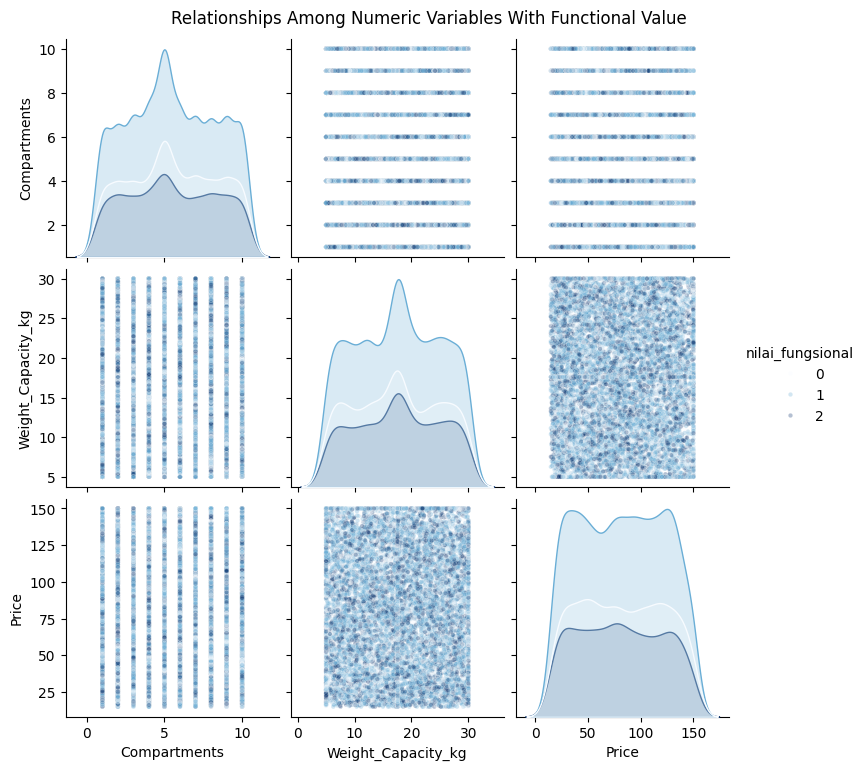

In [22]:
pairplot_cols = ['Compartments', 'Weight_Capacity_kg', 'Price']

sns.pairplot(df_viz[pairplot_cols + ['nilai_fungsional']],
             hue='nilai_fungsional',
             palette='Blues',
             plot_kws={'alpha': 0.3, 's': 10})
plt.suptitle('Relationships Among Numeric Variables With Functional Value\n',
             y=1.02)
plt.show()

# alpha=0.3: point transparency so points don't overlap too heavily
# s=10: point size reduced because the dataset is large

# multivariate analysis to examine relationships among several variables in a single visualization
# nilai_fungsional (functional value) was chosen as the hue because it's the variable of interest in this section

# STATISTICAL ANALYSIS

## PMF

In [23]:
data=df_viz['nilai_fungsional'].tolist()

values=np.unique(data)

pmf={}
n=len(data)
for v in values:
    pmf[v]=data.count(v) / n

for val, prob in pmf.items():
    print(f"PMF(functional value={val})={prob:.2f}")

# nilai_fungsional (functional value) is a discrete variable (0, 1, or 2)
# the PMF calculates the probability of each value occurring in the dataset
# PMF(functional value=0) -> probability that a randomly drawn bag has no features at all
# PMF(functional value=1) -> probability that a randomly drawn bag has one feature
# PMF(functional value=2) -> probability that a randomly drawn bag has both features

PMF(functional value=0)=0.28
PMF(functional value=1)=0.50
PMF(functional value=2)=0.22


## KOLMOGOROV-SMIRNOV TEST

In [24]:
from scipy import stats
alpha = 0.05

# using df_viz (Price without NaN), consistent with all analysis involving Price

price_bersih = df_viz['Price']

# KS test chosen over Shapiro-Wilk because the dataset is large (n > 12,000)
# H0: the data follows the distribution being tested
# the smaller the D statistic -> the closer the data is to the tested distribution

# Normality test
ks_normality = stats.kstest(price_bersih, 'norm',
                       args=(price_bersih.mean(), price_bersih.std()))
print("Deviation from Normal?: D =", round(ks_normality.statistic, 4),
      ", p =", round(ks_normality.pvalue, 4))
if ks_normality.pvalue > alpha:
    print("Fail to reject H0: not enough evidence that the data is non-normal")
else:
    print("Reject H0: enough evidence that the data is not normally distributed")

# Uniformity test
ks_uniform = stats.kstest(price_bersih, 'uniform',
                       args=(price_bersih.min(),
                             price_bersih.max() - price_bersih.min()))
print("Deviation from Uniform?: D =", round(ks_uniform.statistic, 4),
      ", p =", round(ks_uniform.pvalue, 4))
if ks_uniform.pvalue > alpha:
    print("Fail to reject H0: not enough evidence that the data is non-uniform")
else:
    print("Reject H0: enough evidence that the data is not fully uniform")

# KS-TEST INTERPRETATION:
# Result: deviation from normal (D=0.0618) > deviation from uniform (D=0.0243)
# Price is closer to a uniform distribution than to a normal one
# the uniform distribution is visually reinforced by the flat histogram

Deviation from Normal?: D = 0.0618 , p = 0.0
Reject H0: enough evidence that the data is not normally distributed
Deviation from Uniform?: D = 0.0243 , p = 0.0
Reject H0: enough evidence that the data is not fully uniform


## T-TEST

In [25]:
from scipy.stats import ttest_ind

alpha = 0.05

# using df_viz (Price without NaN), consistent with all analysis involving Price

# Waterproof-Price
t1, p1 = ttest_ind(df_viz[df_viz['Waterproof_Enc'] == 1]['Price'],
                   df_viz[df_viz['Waterproof_Enc'] == 0]['Price'])

print(f"Waterproof: t={t1:.4f}, p={p1:.4f}")
print("Fail to reject H0: no significant price difference\n" if p1 > alpha else "Reject H0: there is a significant difference\n")

# Laptop-Price
t2, p2 = ttest_ind(df_viz[df_viz['Laptop_Compartment_Enc'] == 1]['Price'],
                   df_viz[df_viz['Laptop_Compartment_Enc'] == 0]['Price'])

print(f"Laptop Compartment: t={t2:.4f}, p={p2:.4f}")
print("Fail to reject H0: no significant price difference\n" if p2 > alpha else "Reject H0: there is a significant price difference\n")

# T-TEST INTERPRETATION:
# both p-values are well above alpha=0.05, meaning there isn't enough statistical evidence that the Waterproof or Laptop Compartment features affect price.

Waterproof: t=-0.7702, p=0.4412
Fail to reject H0: no significant price difference

Laptop Compartment: t=-1.1808, p=0.2377
Fail to reject H0: no significant price difference



# OTHER ATTRIBUTES: VISUALIZATION

## Brand
---
Are certain brands more expensive/cheaper?

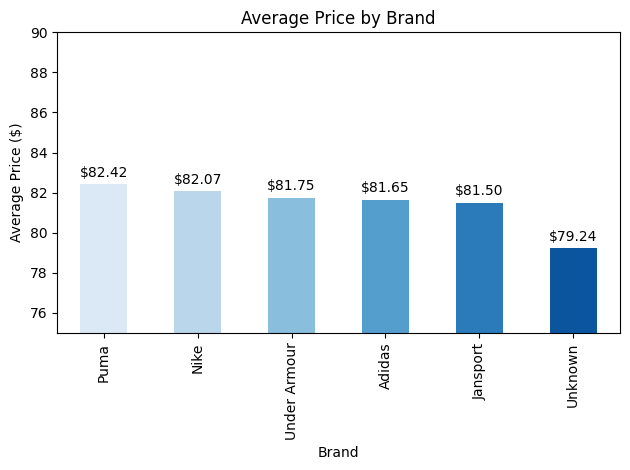

In [26]:
# ['Price'].mean(): calculates average Price per Brand
# sort_values(ascending=False): sort from highest to lowest
# color=sns.color_palette('Blues', 6): 6 distinct shades of blue for each brand
df_viz.groupby('Brand', observed=True)['Price'].mean().sort_values(ascending=False).plot(kind='bar', color=sns.color_palette('Blues', 6))

# bar_label: shows the average value above each bar
# fmt='$%.2f': formats the label as a dollar value with 2 decimals
# padding=3: spacing between the label and the bar end
plt.bar_label(plt.gca().containers[0], fmt='$%.2f', padding=3)
plt.title('Average Price by Brand')
plt.xlabel('Brand')
plt.ylabel('Average Price ($)')
plt.ylim(75, 90) # zoom in the y-axis so differences between brands are more visible
plt.tight_layout()
plt.show()

# INTERPRETATION:
# average prices across brands are very close. The gap between the most expensive (Puma $82.42) and cheapest (Jansport $81.50) is only $0.92.
# in the real world, brands like Nike and Under Armour usually carry a "premium" price compared to Jansport.
# 'Unknown' ($79.24) is slightly lower. Bags without a clear brand tend not to carry brand/premium pricing.

# Brand does not show a significant effect on price.

## Size and Style
---
Do size and style reflect price differences?

/tmp/ipykernel_734/3672433412.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_viz, x='Size', y='Price',
/tmp/ipykernel_734/3672433412.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_viz, x='Style', y='Price',


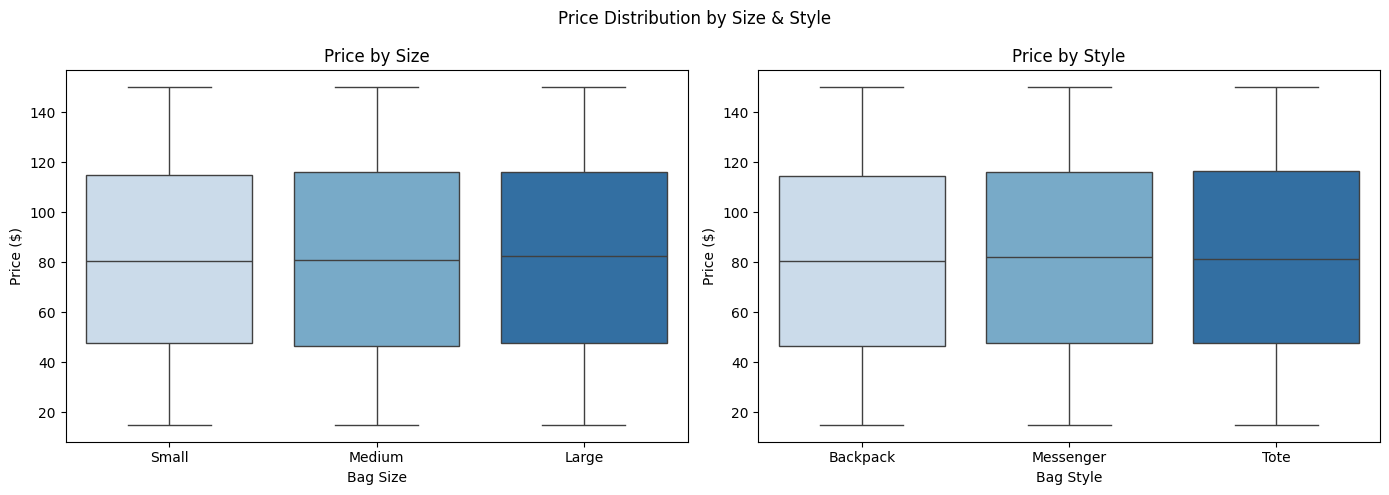

In [27]:
# boxplot: shows median, IQR, and range all at once
# subplot: compares two variables in one view
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Price Distribution by Size & Style')

sns.boxplot(data=df_viz, x='Size', y='Price',
            order=['Small', 'Medium', 'Large'],
            palette='Blues', ax=axes[0])
axes[0].set_title('Price by Size')
axes[0].set_xlabel('Bag Size')
axes[0].set_ylabel('Price ($)')

sns.boxplot(data=df_viz, x='Style', y='Price',
            palette='Blues', ax=axes[1])
axes[1].set_title('Price by Style')
axes[1].set_xlabel('Bag Style')
axes[1].set_ylabel('Price ($)')

plt.tight_layout()
plt.show()

# INTERPRETATION:
# all three sizes (Small, Medium, Large) show an almost identical price distribution.
# the same applies to Style; the three boxes are almost indistinguishable from one another.
# in the real world, Large bags tend to be more expensive than Small ones.

# size and style do not show a significant effect on price in this dataset.

## Material

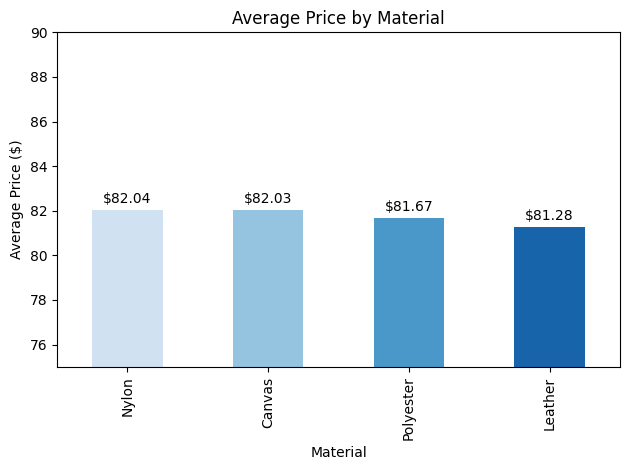

In [28]:
df_viz.groupby('Material', observed=True)['Price'].mean().sort_values(
    ascending=False).plot(
    kind='bar', color=sns.color_palette('Blues', 4))
plt.bar_label(plt.gca().containers[0], fmt='$%.2f', padding=3)
plt.title('Average Price by Material')
plt.xlabel('Material')
plt.ylabel('Average Price ($)')
plt.ylim(75, 90)
plt.tight_layout()
plt.show()

# INTERPRETATION:
# the gap between Nylon ($82.04) and Leather ($81.28) is only $0.76.
# in the real world, Leather is usually far more expensive than Nylon due to a significant difference in production cost.

# material does not show a significant effect on price.

## Color
---
Does the bag's color affect price?

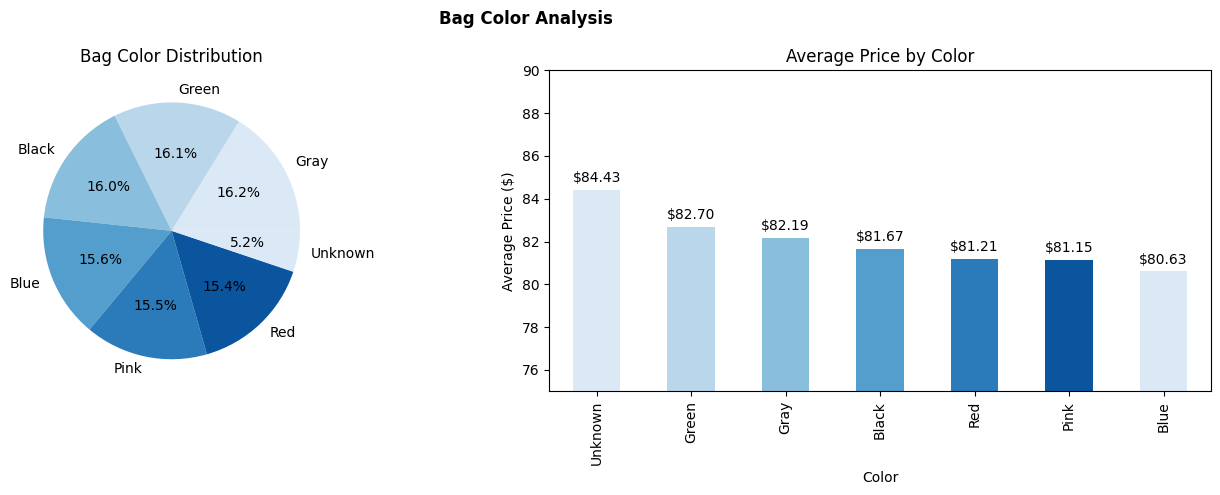

In [29]:
# pie chart chosen because Color only has 6 categories, still easy to read.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# left: color proportion (pie)
df['Color'].value_counts().plot(
    kind='pie', ax=axes[0],
    autopct='%1.1f%%',
    colors=sns.color_palette('Blues', 6))
axes[0].set_title('Bag Color Distribution')
axes[0].set_ylabel('')

# right: average price by color (bar)
df_viz.groupby('Color', observed=True)['Price'].mean().sort_values(
    ascending=False).plot(
    kind='bar', ax=axes[1],
    color=sns.color_palette('Blues', 6))
axes[1].bar_label(axes[1].containers[0], fmt='$%.2f', padding=3)
axes[1].set_title('Average Price by Color')
axes[1].set_xlabel('Color')
axes[1].set_ylabel('Average Price ($)')
axes[1].set_ylim(75, 90)

plt.suptitle('Bag Color Analysis', fontweight='bold')
plt.tight_layout()
plt.show()

# INTERPRETATION:
# color distribution is nearly even (~16-17% each) —
# no color appears dominant.

# average prices across colors are very close ($80.63-$82.70) except 'Unknown' ($84.43), which is slightly higher.
# 'Unknown' being higher here contradicts the Brand finding, where 'Unknown' was actually LOWER ($79.24).
# bags without clear color info are likely a different subset of products than bags without a clear brand. No consistent pattern.
# the maximum gap among known colors is only $2.07

# color does not show a significant effect on price in this dataset.

## Weight Capacity
---
Are bags with a larger/heavier weight capacity more expensive than lower-capacity bags?

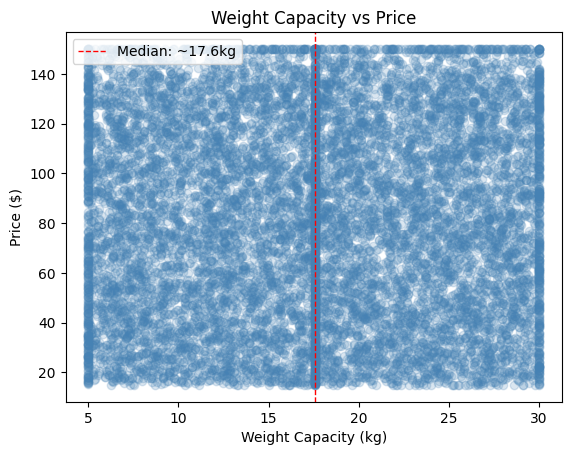

In [30]:
plt.scatter(df_viz['Weight_Capacity_kg'], df_viz['Price'],
            alpha=0.2, color='steelblue')
plt.axvline(df_viz['Weight_Capacity_kg'].median(),
            color='red', linestyle='--', linewidth=1,
            label=f"Median: ~{df_viz['Weight_Capacity_kg'].median():.1f}kg")
plt.legend()
plt.title('Weight Capacity vs Price')
plt.xlabel('Weight Capacity (kg)')
plt.ylabel('Price ($)')
plt.show()

# INTERPRETATION:
# no correlation visible between weight capacity and price; points are scattered evenly across the area with no upward or downward pattern.
# large-capacity bags are not necessarily more expensive.

## Relationships Among Variables

### Heatmap

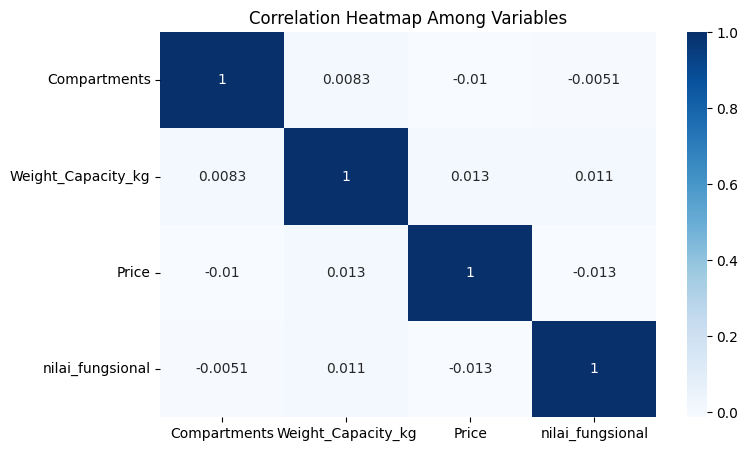

In [31]:
# value close to 0: no linear relationship
numeric_cols = ['Compartments', 'Weight_Capacity_kg', 
                'Price', 'nilai_fungsional']

corr = df_viz[numeric_cols].corr() # .corr(): computes correlation between each pair of variables (bivariate analysis)

plt.figure(figsize=(8, 5))
sns.heatmap(corr, annot=True, cmap='Blues')
plt.title('Correlation Heatmap Among Variables')
plt.show()

# annot=True: shows the correlation value in each cell

# INTERPRETATION:
# almost every variable has a correlation close to zero with Price

# no numeric variable shows a meaningful linear relationship with price

### Interactive Plotly

In [32]:
fig = px.box(df_viz,
             x='Brand',
             y='Price',
             color='Size',
             title='Price Distribution by Brand & Size',
             labels={'Price': 'Price ($)', 'Brand': 'Brand'},
             color_discrete_sequence=['#AED6F1', '#2E86C1', '#1B4F72'],
             category_orders={
                 'Size': ['Small', 'Medium', 'Large'],
                 'Brand': ['Adidas', 'Jansport', 'Nike',
                           'Puma', 'Under Armour', 'Unknown']
             })
fig.show()

# INTERPRETATION:
# this interactive visualization combines three variables at once, allowing exploration of price distribution per brand and size simultaneously. The pattern confirms earlier findings: no meaningful difference across brands or sizes.

# INSIGHTS

1. **NO FACTOR WAS FOUND TO SIGNIFICANTLY INFLUENCE PRICE**

All variables (Brand, Material, Size, Style, Waterproof, Laptop Compartment, Compartments, and Weight Capacity) show a correlation close to zero with price (heatmap).

2. **FUNCTIONAL FEATURES ARE ALREADY A MARKET STANDARD**

The price gap is only $0.55 for Waterproof and $0.85 for Laptop Compartment. Bags with FULL features ($80.83) are actually cheaper on average than bags with NO features ($82.27), contrary to real-world expectations.

3. **BRAND DOES NOT SHOW A SIGNIFICANT PRICE DIFFERENCE**

The average price gap between the most expensive brand (Puma, $82.42) and the cheapest (Jansport, $81.50) is only $0.92, within a $15-$150 price range.

4. **THE DATASET IS LIKELY SYNTHETIC**

Four indicators: a uniform Price distribution, suspiciously clean boundaries (15/150, 5kg/30kg), no meaningful price differences across categories, and Size/Style boxplots that look nearly identical.

5. **RECOMMENDATION FOR CONSUMERS**

891 bags (7.3%) meet the "ideal" criteria (Medium, Laptop Compartment, price ≤ $80). Of those, 413 bags (46.4%) also have Waterproof without any extra cost.

Based on this dataset, consumers don't need to pay more for a particular brand or feature.

# FINAL DATASET

## FINAL ENCODING

In [33]:
from sklearn.preprocessing import OrdinalEncoder

df_final = df.copy()

df_final = df_final.dropna(subset=['Price'])

oe = OrdinalEncoder(categories=[['Small', 'Medium', 'Large']])
df_final['Size'] = oe.fit_transform(df_final[['Size']]).astype(int)

df_final = pd.get_dummies(df_final,
                          columns=['Brand', 'Material', 'Style', 'Color'],
                          dtype=int)

df_final = df_final.drop(columns=['Laptop_Compartment', 'Waterproof'])

print(f"Shape before : {df.shape}")
print(f"Shape after  : {df_final.shape}")

df_final.info()
df_final.head()

# Price NaN rows are dropped. Consistent with how Price is treated throughout the analysis (never filled, only excluded)
# models cannot handle NaN, but filling with median/mean would distort the data's distribution
# all columns are encoded into numbers for further analysis purposes.

Shape before : (12805, 13)
Shape after  : (12181, 27)
<class 'pandas.DataFrame'>
Index: 12181 entries, 0 to 12804
Data columns (total 27 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Size                    12181 non-null  int64  
 1   Compartments            12181 non-null  int64  
 2   Weight_Capacity_kg      12181 non-null  float64
 3   Price                   12181 non-null  float64
 4   Laptop_Compartment_Enc  12181 non-null  int64  
 5   Waterproof_Enc          12181 non-null  int64  
 6   nilai_fungsional        12181 non-null  int64  
 7   Brand_Adidas            12181 non-null  int64  
 8   Brand_Jansport          12181 non-null  int64  
 9   Brand_Nike              12181 non-null  int64  
 10  Brand_Puma              12181 non-null  int64  
 11  Brand_Under Armour      12181 non-null  int64  
 12  Brand_Unknown           12181 non-null  int64  
 13  Material_Canvas         12181 non-null  int64  
 14  

,Size,Compartments,Weight_Capacity_kg,Price,Laptop_Compartment_Enc,Waterproof_Enc,nilai_fungsional,Brand_Adidas,Brand_Jansport,Brand_Nike,...,Style_Backpack,Style_Messenger,Style_Tote,Color_Black,Color_Blue,Color_Gray,Color_Green,Color_Pink,Color_Red,Color_Unknown
0,0,9,9.33,116.655111,0,0,0,0,0,1,...,0,0,1,1,0,0,0,0,0,0
1,2,5,26.26,127.225657,0,0,0,1,0,0,...,1,0,0,0,0,1,0,0,0,0
2,1,7,15.05,132.131249,0,0,0,0,0,0,...,1,0,0,0,1,0,0,0,0,0
4,2,1,12.77,86.334448,0,1,1,0,0,0,...,1,0,0,1,0,0,0,0,0,0
5,1,10,11.04,115.392790,1,0,1,1,0,0,...,0,0,1,1,0,0,0,0,0,0


## RANDOM SAMPLE

In [34]:
sample_df = df.sample(frac=0.1, random_state=42)
sample_final = df_final.sample(frac=0.1, random_state=42)

print(f"Sample size        : {len(sample_final):,} rows")
print(f"Mean Price (full)  : ${df_final['Price'].mean():.2f}")
print(f"Mean Price (sample): ${sample_final['Price'].mean():.2f}")

sample_df[['Brand', 'Size', 'Price', 
           'Waterproof', 'Laptop_Compartment']].head(10)

# INTERPRETATION:
# a 10% sample represents the full dataset reasonably well.
# the sample's mean Price stays close to the full dataset's, with only a small percentage difference.
# every row has an equal chance of being selected (random sampling), supporting the sample's representativeness.

Sample size        : 1,218 rows
Mean Price (full)  : $81.75
Mean Price (sample): $79.55


,Brand,Size,Price,Waterproof,Laptop_Compartment
10192,Unknown,Small,141.158930,Yes,No
12413,Nike,Medium,72.413630,Yes,No
1358,Under Armour,Small,97.262826,Yes,Yes
6595,Adidas,Large,150.000000,Yes,No
7458,Nike,Large,46.274889,No,Yes
8546,Adidas,Medium,113.697354,Yes,Yes
11102,Adidas,Medium,97.832306,Yes,No
8,Jansport,Large,150.000000,No,Yes
311,Jansport,Large,43.411850,No,No
181,Jansport,Small,49.063543,Yes,No


# FINAL DATASET RECOMMENDATION

In [35]:
print("===RECOMMENDED DATA, READY FOR FURTHER ANALYSIS===")
print(f"Initial Shape          : {df.shape}")
print(f"Final Shape             : {df_final.shape}")
print(f"Initial Missing Values : {df.isnull().sum().sum()}")
print(f"Final Missing Values   : {df_final.isnull().sum().sum()}")

print("===VIEW===")
print("BEFORE:")
display(df.head())

print("RECOMMENDED DATASET, READY FOR FURTHER ANALYSIS:")
display(df_final.head())

# comparison of df (analysis-ready) vs df_final (modeling-ready).
# df_final has more columns due to one-hot encoding.

===RECOMMENDED DATA, READY FOR FURTHER ANALYSIS===
Initial Shape          : (12805, 13)
Final Shape             : (12181, 27)
Initial Missing Values : 624
Final Missing Values   : 0
===VIEW===
BEFORE:


,Brand,Material,Size,Compartments,Laptop_Compartment,Waterproof,Style,Color,Weight_Capacity_kg,Price,Laptop_Compartment_Enc,Waterproof_Enc,nilai_fungsional
0,Nike,Nylon,Small,9,No,No,Tote,Black,9.33,116.655111,0,0,0
1,Adidas,Polyester,Large,5,No,No,Backpack,Gray,26.26,127.225657,0,0,0
2,Under Armour,Nylon,Medium,7,No,No,Backpack,Blue,15.05,132.131249,0,0,0
3,Under Armour,Canvas,Large,8,Yes,No,Tote,Green,17.43,NaN,1,0,1
4,Puma,Polyester,Large,1,No,Yes,Backpack,Black,12.77,86.334448,0,1,1


RECOMMENDED DATASET, READY FOR FURTHER ANALYSIS:


,Size,Compartments,Weight_Capacity_kg,Price,Laptop_Compartment_Enc,Waterproof_Enc,nilai_fungsional,Brand_Adidas,Brand_Jansport,Brand_Nike,...,Style_Backpack,Style_Messenger,Style_Tote,Color_Black,Color_Blue,Color_Gray,Color_Green,Color_Pink,Color_Red,Color_Unknown
0,0,9,9.33,116.655111,0,0,0,0,0,1,...,0,0,1,1,0,0,0,0,0,0
1,2,5,26.26,127.225657,0,0,0,1,0,0,...,1,0,0,0,0,1,0,0,0,0
2,1,7,15.05,132.131249,0,0,0,0,0,0,...,1,0,0,0,1,0,0,0,0,0
4,2,1,12.77,86.334448,0,1,1,0,0,0,...,1,0,0,1,0,0,0,0,0,0
5,1,10,11.04,115.392790,1,0,1,1,0,0,...,0,0,1,1,0,0,0,0,0,0


# CONCLUSION

Mini Project 2 continues the exploration from Mini Project 1 using a visual approach to answer the question:

**Are functional features (Waterproof & Laptop Compartment) reflected in the bag's price? Or are there other attributes that matter more?**

Through visualization and EDA techniques, no factor was found to significantly influence price formation.

This dataset is most likely synthetic, with prices randomly "generated" within a $15-$150 range, regardless of any attribute.

LIMITATIONS:
1. No time context (transaction date/period)
2. No real sales data
3. Lacking other supporting variables (such as location, rating, etc.)

RECOMMENDATIONS FOR FURTHER ANALYSIS:
- K-Means Clustering: segmentation based on non-price attributes (no normality assumption required)
- Decision Tree: predicting price segments without parametric assumptions (fits Price's uniform distribution)